<a href="https://colab.research.google.com/github/Rabin-2468/Artificial-Intelligence-and-Machine-Learning/blob/main/2431876_Rabindra_SahSpamHam_RNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part III – Spam vs Ham SMS Text Classification using RNN, LSTM and Pretrained Embeddings

**Dataset:** Spam vs Ham SMS Dataset  
**Task:** Binary text classification: `ham = 0`, `spam = 1`

This notebook is written for the Part III language task. It follows the assignment flow:

1. Load and understand the dataset.
2. Clean the text: lowercase, remove URLs/mentions/hashtags/numbers/special characters, expand contractions, remove stopwords and lemmatize.
3. Visualize the dataset and cleaned words.
4. Tokenize using Keras `Tokenizer` and apply percentile-based sequence padding.
5. Split data into train/validation/test.
6. Train three models:
   - Simple RNN with trainable Embedding
   - LSTM with trainable Embedding
   - LSTM with pretrained Word2Vec/GloVe-style embeddings from `gensim`
7. Evaluate using accuracy, confusion matrix, classification report, precision, recall and F1-score.
8. Perform error analysis with incorrect predictions.
9. Provide a simple real-time prediction function and optional Gradio interface.

> Before final submission, rename this notebook as: `WLVID_FullName(firstname+last).ipynb`.

## 1. Install and import required libraries

Run this cell first in Google Colab. If a package is already installed, the command will finish quickly.

In [1]:
# Install extra libraries if needed. In Google Colab this is usually safe.
# gensim is used for pretrained embeddings, contractions for text normalization, wordcloud for visualization.
!pip -q install contractions gensim wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00


In [2]:
import os
import re
import html
import time
import zipfile
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
GPU available: False


## 2. Download NLTK resources

These resources support stopword removal and lemmatization.

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

## 3. Locate and extract the dataset zip file

Upload the dataset zip file in Colab or keep it in the same directory as this notebook. The code searches common paths automatically.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from pathlib import Path

# IMPORTANT: Change this path to where your *extracted* dataset files are located in Google Drive.
extract_dir = Path('/content/drive/MyDrive/AI ML/Assignment/Part3/9.Spam vs Ham Sms Dataset')

# Ensure the directory exists (optional, as it should already exist if extracted)
extract_dir.mkdir(parents=True, exist_ok=True)

print('Assuming extracted dataset is in:', extract_dir.resolve())

Assuming extracted dataset is in: /content/drive/MyDrive/AI ML/Assignment/Part3/9.Spam vs Ham Sms Dataset


## 4. Load the CSV file and fix raw text columns

The provided SMS dataset uses `latin1` encoding and contains extra unnamed columns because some SMS messages contain unusual quotation/comma formatting. To avoid losing text, the notebook merges `v2` and all `Unnamed` text-fragment columns into one complete `text` column.

In [6]:
# Find the CSV file automatically.
csv_files = list(extract_dir.rglob('*.csv'))
if not csv_files:
    raise FileNotFoundError('No CSV file found after extraction.')

csv_path = csv_files[0]
print('CSV path:', csv_path)

# UTF-8 fails for this dataset, so latin1 is used.
raw_df = pd.read_csv(csv_path, encoding='latin1')
print('Raw shape:', raw_df.shape)
print('Raw columns:', raw_df.columns.tolist())
raw_df.head()

CSV path: /content/drive/MyDrive/AI ML/Assignment/Part3/9.Spam vs Ham Sms Dataset/spamvsham.csv
Raw shape: (5572, 5)
Raw columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
# Merge possible message-fragment columns into one text column.
label_col = 'v1'
text_fragment_cols = [col for col in raw_df.columns if col != label_col]

df = raw_df.copy()
df['label'] = df[label_col].astype(str).str.lower().str.strip()
df['text'] = (
    df[text_fragment_cols]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

df = df[['label', 'text']]

print('Prepared shape:', df.shape)
print(df.head())
print('\nLabel values:')
print(df['label'].value_counts())

Prepared shape: (5572, 2)
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label values:
label
ham     4825
spam     747
Name: count, dtype: int64


## 5. Dataset audit: missing values, duplicates and class imbalance

This section checks common dataset problems before modelling.

Total rows: 5572
Missing labels: 0
Missing/empty texts: 0

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64
Imbalance ratio before duplicate removal: 6.46:1

Exact duplicate rows with same label and text: 414
Duplicate SMS texts: 414
Duplicate SMS texts with conflicting labels: 0


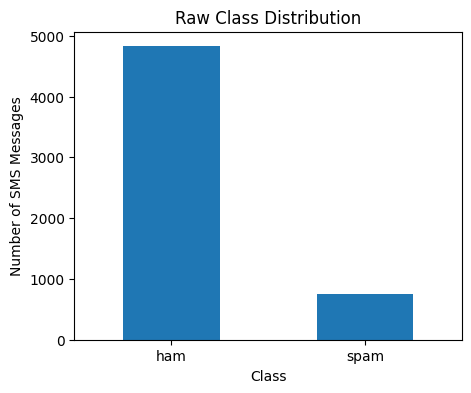

In [8]:
print('Total rows:', len(df))
print('Missing labels:', df['label'].isna().sum())
print('Missing/empty texts:', df['text'].isna().sum() + (df['text'].str.len() == 0).sum())

print('\nClass distribution:')
class_counts_raw = df['label'].value_counts()
print(class_counts_raw)

imbalance_ratio_raw = class_counts_raw.max() / class_counts_raw.min()
print(f'Imbalance ratio before duplicate removal: {imbalance_ratio_raw:.2f}:1')

exact_duplicate_count = df.duplicated(subset=['label', 'text']).sum()
text_duplicate_count = df.duplicated(subset=['text']).sum()
conflicting_duplicate_texts = df.groupby('text')['label'].nunique().gt(1).sum()

print('\nExact duplicate rows with same label and text:', exact_duplicate_count)
print('Duplicate SMS texts:', text_duplicate_count)
print('Duplicate SMS texts with conflicting labels:', conflicting_duplicate_texts)

# Plot raw class distribution.
plt.figure(figsize=(5, 4))
class_counts_raw.plot(kind='bar')
plt.title('Raw Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of SMS Messages')
plt.xticks(rotation=0)
plt.show()

### Cleaning decision

The dataset has repeated SMS messages. Exact duplicate messages are removed **before splitting** so that the same SMS does not appear in both training and testing data. The class imbalance is handled later using stratified splitting and class weights.

Rows after removing duplicate SMS texts: 5158

Class distribution after duplicate removal:
label
ham     4516
spam     642
Name: count, dtype: int64
Imbalance ratio after duplicate removal: 7.03:1


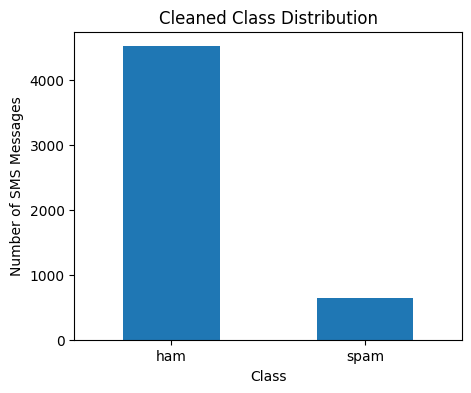

In [9]:
# Remove empty text and exact duplicate SMS texts before splitting to reduce leakage.
df = df[df['text'].str.len() > 0].copy()
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

print('Rows after removing duplicate SMS texts:', len(df))
print('\nClass distribution after duplicate removal:')
class_counts_clean = df['label'].value_counts()
print(class_counts_clean)

imbalance_ratio_clean = class_counts_clean.max() / class_counts_clean.min()
print(f'Imbalance ratio after duplicate removal: {imbalance_ratio_clean:.2f}:1')

plt.figure(figsize=(5, 4))
class_counts_clean.plot(kind='bar')
plt.title('Cleaned Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of SMS Messages')
plt.xticks(rotation=0)
plt.show()

## 6. Text cleaning function

The assignment requires lowercase conversion, removing URLs, mentions, hashtags, numbers and special characters, handling contractions, removing stopwords and lemmatization. For spam detection, negation words such as `not`, `no` and `never` are kept because they can change meaning.

In [10]:
stop_words = set(stopwords.words('english'))
# Keep negation words because they can be meaningful in classification.
negation_words = {'no', 'nor', 'not', 'never'}
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    # Clean SMS text for RNN/LSTM modelling.
    text = str(text)
    text = html.unescape(text)                         # convert &amp; etc.
    text = text.lower()                                # lowercase
    text = contractions.fix(text)                      # don't -> do not
    text = re.sub(r'http\S+|www\.\S+', ' ', text)     # remove URLs
    text = re.sub(r'@\w+', ' ', text)                  # remove mentions
    text = re.sub(r'#', ' ', text)                     # remove hashtag symbol
    text = re.sub(r'\d+', ' ', text)                   # remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)              # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()           # normalize spaces

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)


df['clean_text'] = df['text'].apply(clean_text)

# Remove any rows that became empty after cleaning.
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

df[['label', 'text', 'clean_text']].head(10)

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,dun say early hor c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah not think go usf life around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week no word back would li...
6,ham,Even my brother is not like to speak with me. ...,even brother not like speak treat like aid patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,spam,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,spam,Had your mobile 11 months or more? U R entitle...,mobile month r entitled update latest colour m...


## 7. Exploratory visualization after cleaning

The plots below show message length and most frequent cleaned words. These can be used in the report dataset analysis section.

count    5150.000000
mean        8.577087
std         6.156515
min         1.000000
25%         4.000000
50%         7.000000
75%        12.000000
max        74.000000
Name: word_count, dtype: float64


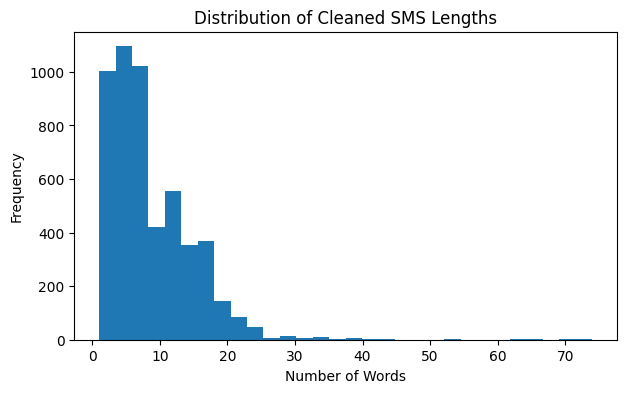

In [11]:
df['word_count'] = df['clean_text'].str.split().apply(len)

print(df['word_count'].describe())

plt.figure(figsize=(7, 4))
plt.hist(df['word_count'], bins=30)
plt.title('Distribution of Cleaned SMS Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

       word  count
0       not    981
1      call    534
2       get    382
3        no    343
4        go    304
5      know    288
6        ok    261
7       day    254
8      want    250
9      free    248
10      got    246
11     like    239
12     time    238
13     love    235
14     come    235
15    going    232
16     good    230
17     text    204
18  message    194
19     need    181


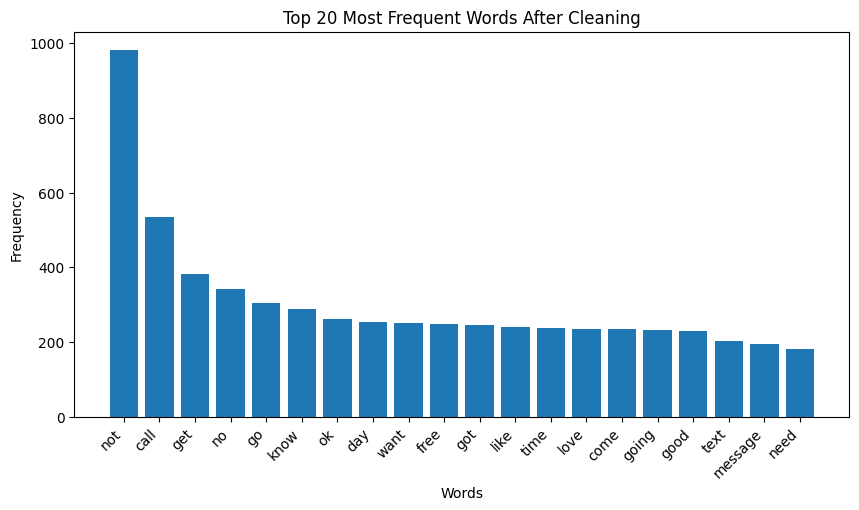

In [12]:
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)
common_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])
print(common_words)

plt.figure(figsize=(10, 5))
plt.bar(common_words['word'], common_words['count'])
plt.title('Top 20 Most Frequent Words After Cleaning')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.show()

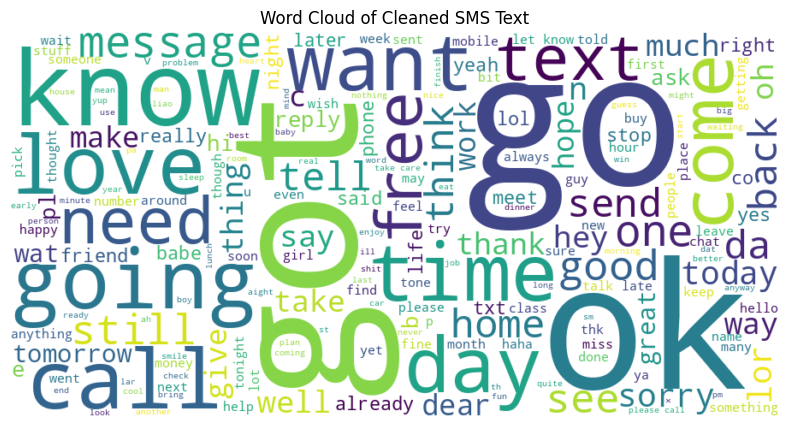

In [13]:
# Optional word cloud visualization.
try:
    from wordcloud import WordCloud
    wc = WordCloud(width=900, height=450, background_color='white').generate(' '.join(df['clean_text']))
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Cleaned SMS Text')
    plt.show()
except Exception as e:
    print('WordCloud skipped:', e)

## 8. Label encoding and train/validation/test split

The dataset is binary:

- `ham = 0`
- `spam = 1`

The main train-test split is 80/20 as required. From the 80% training part, a validation split is created for training curves and early stopping.

In [14]:
label_map = {'ham': 0, 'spam': 1}
reverse_label_map = {0: 'ham', 1: 'spam'}

df['label_num'] = df['label'].map(label_map)

if df['label_num'].isna().sum() > 0:
    raise ValueError('Unexpected labels found. Check label names in the dataset.')

X_text = df['clean_text'].values
y = df['label_num'].values.astype('int32')

# 80% train+validation, 20% test, stratified to preserve class ratio.
X_trainval_text, X_test_text, y_trainval, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Create validation set from the training portion.
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_trainval_text,
    y_trainval,
    test_size=0.20,
    random_state=SEED,
    stratify=y_trainval
)

print('Train size:', len(X_train_text))
print('Validation size:', len(X_val_text))
print('Test size:', len(X_test_text))
print('Train class distribution:', Counter(y_train))
print('Validation class distribution:', Counter(y_val))
print('Test class distribution:', Counter(y_test))

Train size: 3296
Validation size: 824
Test size: 1030
Train class distribution: Counter({np.int32(0): 2885, np.int32(1): 411})
Validation class distribution: Counter({np.int32(0): 721, np.int32(1): 103})
Test class distribution: Counter({np.int32(0): 902, np.int32(1): 128})


## 9. Tokenization and percentile-based sequence padding

The tokenizer is fitted only on training text to avoid data leakage. The padding length is selected using the 95th percentile of training sequence lengths, so extremely long SMS messages do not force unnecessary padding for all samples.

In [15]:
MAX_WORDS = 10000
OOV_TOKEN = '<OOV>'

# Fit tokenizer only on training data.
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)
val_sequences = tokenizer.texts_to_sequences(X_val_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)

sequence_lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(sequence_lengths, 95))
MAX_LEN = max(MAX_LEN, 10)  # avoid too-small values

print('Vocabulary size found:', len(tokenizer.word_index) + 1)
print('Vocabulary size used:', min(MAX_WORDS, len(tokenizer.word_index) + 1))
print('95th percentile sequence length:', MAX_LEN)

X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_val = pad_sequences(val_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print('X_test shape:', X_test.shape)

Vocabulary size found: 5487
Vocabulary size used: 5487
95th percentile sequence length: 19
X_train shape: (3296, 19)
X_val shape: (824, 19)
X_test shape: (1030, 19)


## 10. Class weights for imbalance handling

Spam messages are the minority class, so class weights are used during training. This helps the model pay more attention to spam messages instead of simply predicting the majority ham class.

In [16]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print('Class weights:', class_weight)

Class weights: {0: 0.5712305025996534, 1: 4.009732360097324}


## 11. Helper functions for training, plotting and evaluation

In [17]:
EPOCHS = 10
BATCH_SIZE = 64
EMBEDDING_DIM = 64

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]


def plot_history(history, title):
    # Plot training vs validation accuracy and loss.
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df['loss'], label='Training Loss')
    plt.plot(history_df['val_loss'], label='Validation Loss')
    plt.title(f'{title}: Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_df['accuracy'], label='Training Accuracy')
    plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title}: Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


def train_model(model, model_name):
    # Compile and train a model, returning history and training time.
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )

    print(f'\nTraining {model_name}...')
    start_time = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1
    )
    training_time = time.perf_counter() - start_time
    print(f'{model_name} training time: {training_time:.2f} seconds')
    return history, training_time


def evaluate_model(model, model_name):
    # Evaluate model using accuracy, precision, recall, F1, confusion matrix and classification report.
    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f'\n{model_name} Evaluation')
    print('-' * 50)
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam'], zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
    disp.plot(values_format='d')
    plt.title(f'{model_name}: Confusion Matrix')
    plt.show()

    return {
        'model': model_name,
        'accuracy': acc,
        'precision_spam': precision,
        'recall_spam': recall,
        'f1_spam': f1,
        'parameters': model.count_params()
    }, y_pred, y_prob

## 12. Model 1: Simple RNN with trainable Embedding layer

This model uses a trainable embedding layer followed by a SimpleRNN layer. It is the simplest recurrent baseline.

In [18]:
def build_simple_rnn_model():
    model = models.Sequential(name='Simple_RNN_Trainable_Embedding')
    model.add(layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
    model.add(layers.SpatialDropout1D(0.2))
    model.add(layers.SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

rnn_model = build_simple_rnn_model()
rnn_model.summary()

Model: "Simple_RNN_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Simple RNN...
Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.6620 - loss: 0.5971 - val_accuracy: 0.8871 - val_loss: 0.3182 - learning_rate: 0.0010
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8908 - loss: 0.3913 - val_accuracy: 0.9345 - val_loss: 0.2603 - learning_rate: 0.0010
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9284 - loss: 0.3183 - val_accuracy: 0.9454 - val_loss: 0.2261 - learning_rate: 0.0010
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9569 - loss: 0.2458 - val_accuracy: 0.9430 - val_loss: 0.2120 - learning_rate: 0.0010
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9672 - loss: 0.2031 - val_accuracy: 0.9284 - val_loss: 0.3088 - learning_rate: 0.0010
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9766 - loss: 0.1633 - val_accuracy: 0.9587 - val_loss: 0.1739 - learning_rate: 0.0010
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9794 

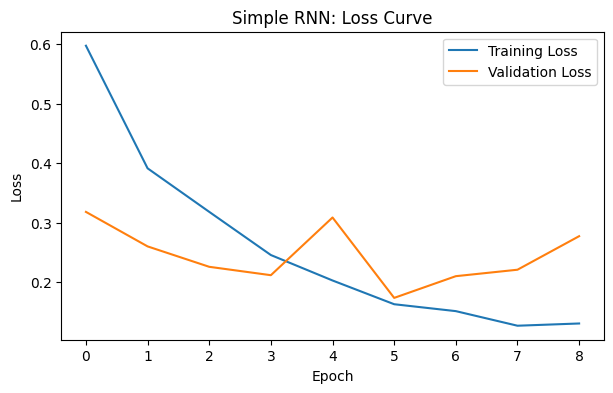

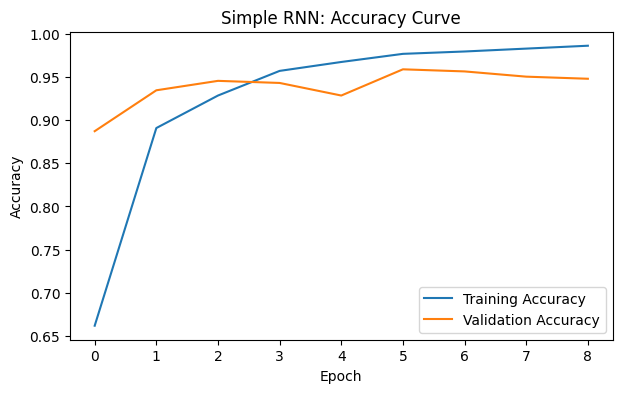

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Simple RNN Evaluation
--------------------------------------------------
Accuracy : 0.9728
Precision: 0.9630
Recall   : 0.8125
F1-score : 0.8814

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       902
        spam       0.96      0.81      0.88       128

    accuracy                           0.97      1030
   macro avg       0.97      0.90      0.93      1030
weighted avg       0.97      0.97      0.97      1030



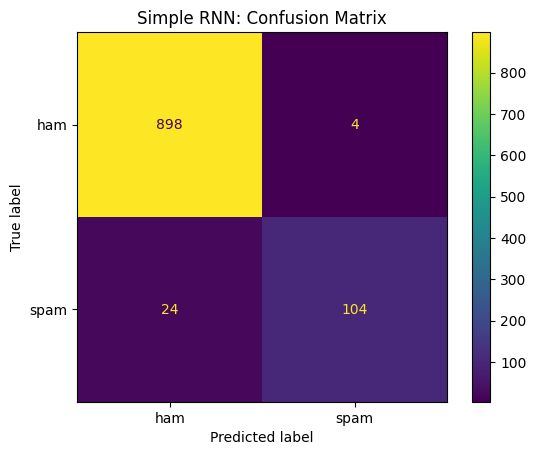

In [19]:
rnn_history, rnn_time = train_model(rnn_model, 'Simple RNN')
plot_history(rnn_history, 'Simple RNN')
rnn_metrics, rnn_pred, rnn_prob = evaluate_model(rnn_model, 'Simple RNN')
rnn_metrics['training_time_sec'] = rnn_time

## 13. Model 2: LSTM with trainable Embedding layer

LSTM is designed to handle longer dependencies better than SimpleRNN, so it is expected to perform more consistently on text classification tasks.

In [20]:
def build_lstm_model():
    model = models.Sequential(name='LSTM_Trainable_Embedding')
    model.add(layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
    model.add(layers.SpatialDropout1D(0.2))
    model.add(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.8847 - loss: 0.4927 - val_accuracy: 0.9478 - val_loss: 0.1768 - learning_rate: 0.0010
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9772 - loss: 0.1566 - val_accuracy: 0.9636 - val_loss: 0.1304 - learning_rate: 0.0010
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9903 - loss: 0.0685 - val_accuracy: 0.9600 - val_loss: 0.1707 - learning_rate: 0.0010
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9903 - loss: 0.0708 - val_accuracy: 0.9600 - val_loss: 0.1714 - learning_rate: 0.0010
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9954 - loss: 0.0277 - val_accuracy: 0.9612 - val_loss: 0.1570 - learning_rate: 5.0000e-04
LSTM training time: 17.30 seconds


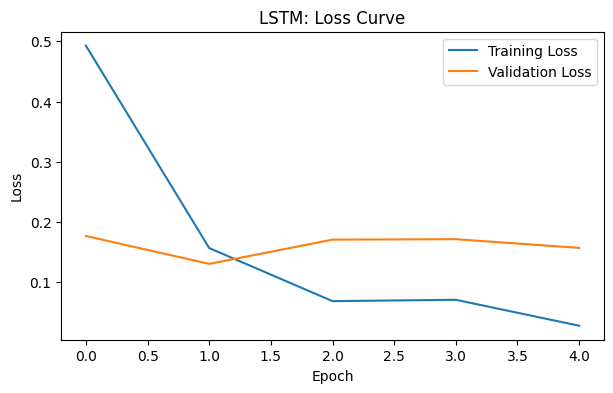

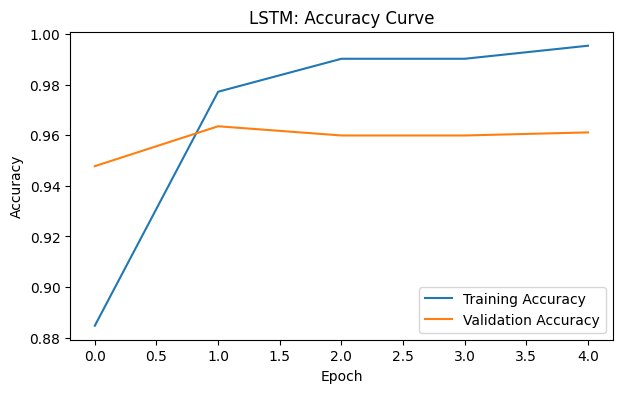

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

LSTM Evaluation
--------------------------------------------------
Accuracy : 0.9757
Precision: 0.9055
Recall   : 0.8984
F1-score : 0.9020

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       902
        spam       0.91      0.90      0.90       128

    accuracy                           0.98      1030
   macro avg       0.95      0.94      0.94      1030
weighted avg       0.98      0.98      0.98      1030



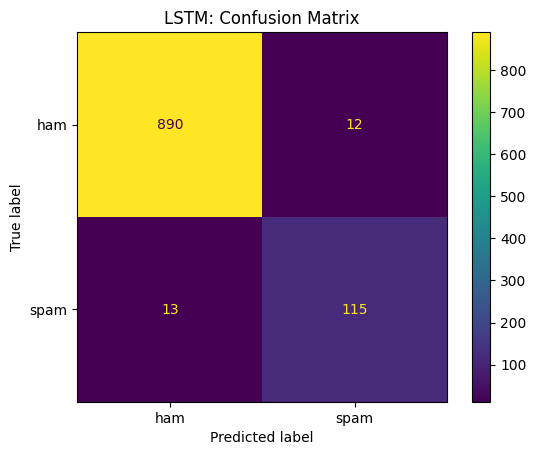

In [21]:
lstm_history, lstm_time = train_model(lstm_model, 'LSTM')
plot_history(lstm_history, 'LSTM')
lstm_metrics, lstm_pred, lstm_prob = evaluate_model(lstm_model, 'LSTM')
lstm_metrics['training_time_sec'] = lstm_time

## 14. Model 3: LSTM with pretrained Word2Vec/GloVe-style embeddings

The assignment asks for a model using pretrained Word2Vec embeddings. The code below uses `gensim.downloader` to load `glove-wiki-gigaword-50`, which is a pretrained word-vector model. It is used in the same way as Word2Vec embeddings: every word is represented by a dense pretrained vector.

If the download fails in Colab, run the install cell again and restart the runtime.

In [22]:
import gensim.downloader as api

EMBEDDING_SOURCE = 'glove-wiki-gigaword-50'
PRETRAINED_EMBEDDING_DIM = 50

print('Loading pretrained embeddings:', EMBEDDING_SOURCE)
embedding_model = api.load(EMBEDDING_SOURCE)
print('Pretrained embedding loaded.')

Loading pretrained embeddings: glove-wiki-gigaword-50
[==================================================] 100.0% 66.0/66.0MB downloaded
Pretrained embedding loaded.


In [23]:
embedding_matrix = np.zeros((VOCAB_SIZE, PRETRAINED_EMBEDDING_DIM), dtype='float32')
found_words = 0

for word, index in tokenizer.word_index.items():
    if index >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]
        found_words += 1

coverage = found_words / (VOCAB_SIZE - 1)
print(f'Words covered by pretrained embeddings: {found_words}/{VOCAB_SIZE - 1} ({coverage:.2%})')

Words covered by pretrained embeddings: 4605/5486 (83.94%)


In [24]:
def build_lstm_pretrained_model():
    model = models.Sequential(name='LSTM_Pretrained_Embedding')
    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=PRETRAINED_EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ))
    model.add(layers.SpatialDropout1D(0.2))
    model.add(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

pretrained_lstm_model = build_lstm_pretrained_model()
pretrained_lstm_model.summary()

Model: "LSTM_Pretrained_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       274,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,350 (1.05 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 274,350 (1.05 MB)


Training LSTM with Pretrained Embeddings...
Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8246 - loss: 0.5731 - val_accuracy: 0.9430 - val_loss: 0.2005 - learning_rate: 0.0010
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8975 - loss: 0.3028 - val_accuracy: 0.9527 - val_loss: 0.1470 - learning_rate: 0.0010
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9287 - loss: 0.2469 - val_accuracy: 0.9636 - val_loss: 0.1313 - learning_rate: 5.0000e-04
LSTM with Pretrained Embeddings training time: 10.96 seconds


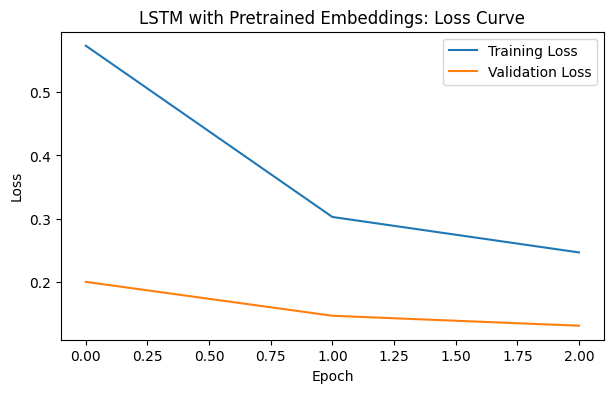

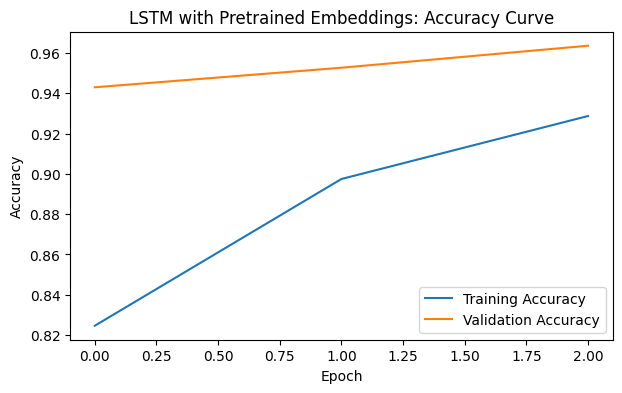

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step

LSTM with Pretrained Embeddings Evaluation
--------------------------------------------------
Accuracy : 0.9437
Precision: 0.7273
Recall   : 0.8750
F1-score : 0.7943

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.95      0.97       902
        spam       0.73      0.88      0.79       128

    accuracy                           0.94      1030
   macro avg       0.85      0.91      0.88      1030
weighted avg       0.95      0.94      0.95      1030



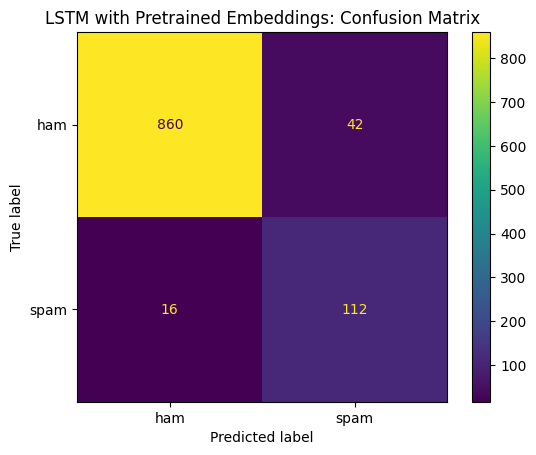

In [25]:
pretrained_history, pretrained_time = train_model(pretrained_lstm_model, 'LSTM with Pretrained Embeddings')
plot_history(pretrained_history, 'LSTM with Pretrained Embeddings')
pretrained_metrics, pretrained_pred, pretrained_prob = evaluate_model(pretrained_lstm_model, 'LSTM with Pretrained Embeddings')
pretrained_metrics['training_time_sec'] = pretrained_time

## 15. Compare Model 1 vs Model 2 vs Model 3

This comparison covers accuracy, spam-class precision, spam-class recall, spam-class F1-score, model parameters and training time.

In [26]:
results_df = pd.DataFrame([rnn_metrics, lstm_metrics, pretrained_metrics])
results_df

,model,accuracy,precision_spam,recall_spam,f1_spam,parameters,training_time_sec
0,Simple RNN,0.972816,0.962963,0.812500,0.881356,361537,13.641506
1,LSTM,0.975728,0.905512,0.898438,0.901961,386305,17.300925
2,LSTM with Pretrained Embeddings,0.943689,0.727273,0.875000,0.794326,305903,10.959419


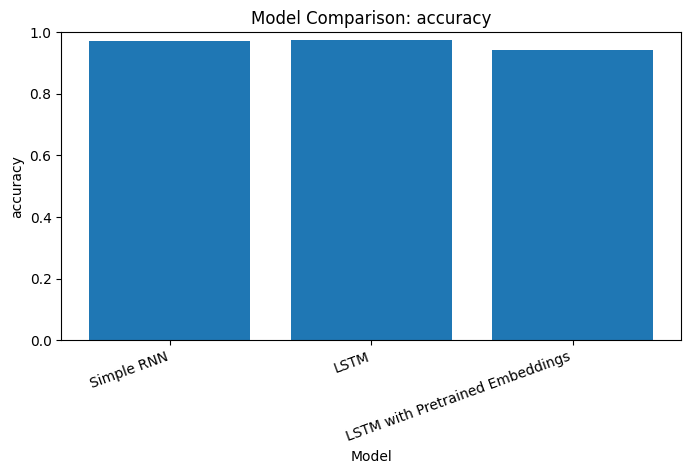

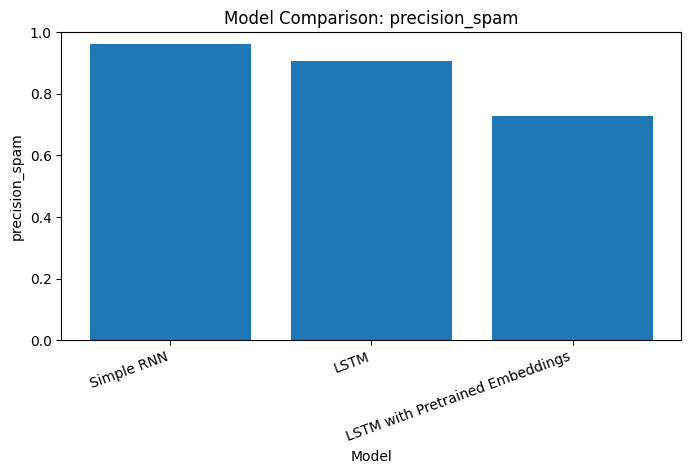

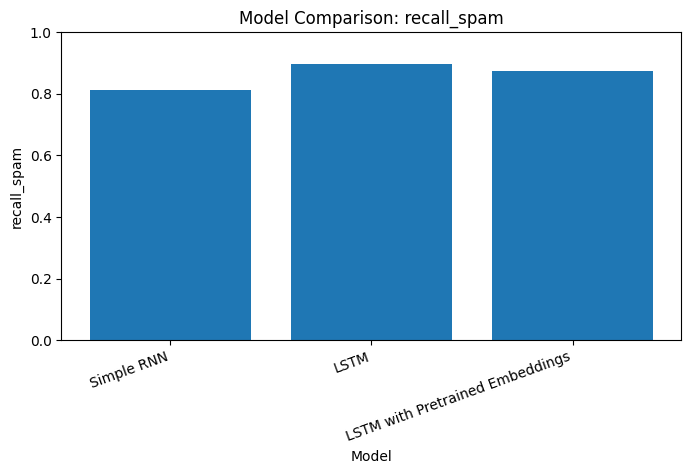

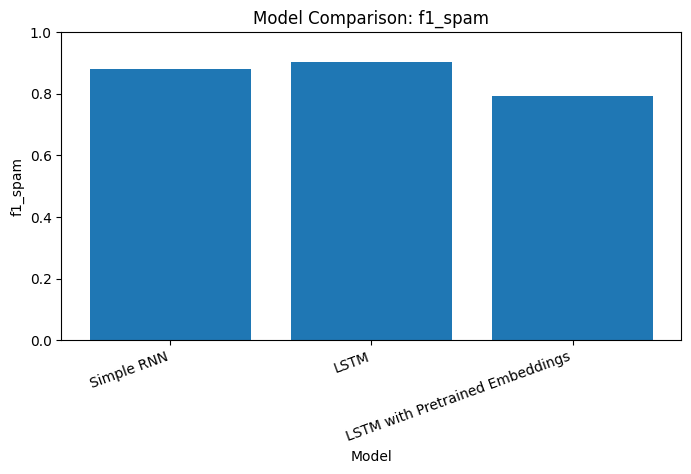

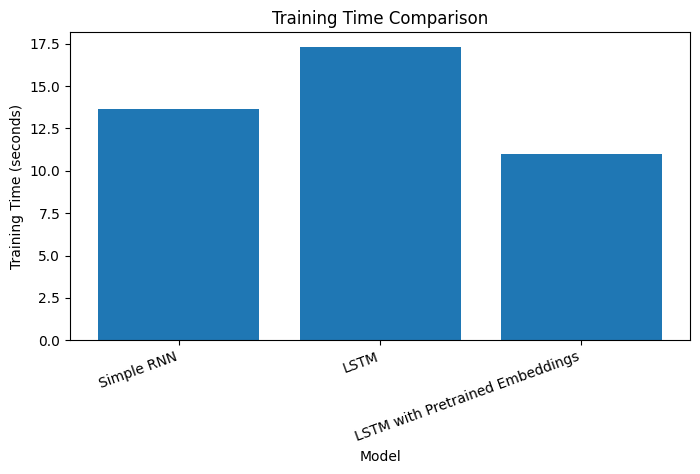

In [27]:
metrics_to_plot = ['accuracy', 'precision_spam', 'recall_spam', 'f1_spam']

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 4))
    plt.bar(results_df['model'], results_df[metric])
    plt.title(f'Model Comparison: {metric}')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha='right')
    plt.ylim(0, 1)
    plt.show()

plt.figure(figsize=(8, 4))
plt.bar(results_df['model'], results_df['training_time_sec'])
plt.title('Training Time Comparison')
plt.xlabel('Model')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=20, ha='right')
plt.show()

## 16. Error analysis: misclassified examples

This section selects the best model based on spam F1-score and shows incorrect predictions. Use these examples in the report to explain why mistakes happened.

In [28]:
# Select best model based on spam F1-score.
best_row = results_df.sort_values('f1_spam', ascending=False).iloc[0]
best_model_name = best_row['model']
print('Best model based on spam F1-score:', best_model_name)

if best_model_name == 'Simple RNN':
    best_pred = rnn_pred
    best_prob = rnn_prob
elif best_model_name == 'LSTM':
    best_pred = lstm_pred
    best_prob = lstm_prob
else:
    best_pred = pretrained_pred
    best_prob = pretrained_prob

error_df = pd.DataFrame({
    'text': X_test_text,
    'actual': [reverse_label_map[int(v)] for v in y_test],
    'predicted': [reverse_label_map[int(v)] for v in best_pred],
    'spam_probability': best_prob
})

misclassified = error_df[error_df['actual'] != error_df['predicted']]
print('Number of misclassified test examples:', len(misclassified))
misclassified.head(5)

Best model based on spam F1-score: LSTM
Number of misclassified test examples: 25


,text,actual,predicted,spam_probability
28,sorry missed call let u talk time,spam,ham,0.012329
33,received mobile content enjoy,spam,ham,0.392024
119,pleased inform application airtel broadband pr...,ham,spam,0.952347
166,hi missed call mumhas beendropping red wine th...,ham,spam,0.949606
178,free give otherwise nalla adi entey nattil kittum,ham,spam,0.957803


In [29]:
# Print 2-3 incorrect predictions for the report.
for i, row in misclassified.head(3).iterrows():
    print('SMS:', row['text'])
    print('Actual:', row['actual'])
    print('Predicted:', row['predicted'])
    print('Spam probability:', round(row['spam_probability'], 4))
    print('-' * 80)

SMS: sorry missed call let u talk time
Actual: spam
Predicted: ham
Spam probability: 0.0123
--------------------------------------------------------------------------------
SMS: received mobile content enjoy
Actual: spam
Predicted: ham
Spam probability: 0.392
--------------------------------------------------------------------------------
SMS: pleased inform application airtel broadband processed successfully installation happen within day
Actual: ham
Predicted: spam
Spam probability: 0.9523
--------------------------------------------------------------------------------


## 17. Short interpretation template for the report

After running the notebook, replace the bracketed values with your actual output.

- The dataset contained SMS messages labelled as ham or spam. It showed class imbalance because ham messages were much more common than spam messages.
- Duplicate SMS texts were removed before splitting to reduce train-test leakage.
- Text was cleaned by lowercasing, removing URLs, mentions, hashtags, numbers and special characters, expanding contractions, removing stopwords and applying lemmatization.
- Keras Tokenizer converted cleaned SMS messages into integer sequences. The maximum sequence length was selected using the 95th percentile to avoid excessive padding.
- The Simple RNN model achieved [insert accuracy/F1].
- The LSTM model achieved [insert accuracy/F1].
- The pretrained embedding LSTM achieved [insert accuracy/F1].
- The best model was [insert model name], mainly because it gave the highest spam F1-score, which is important for spam detection.
- Some mistakes occurred because short SMS messages can be ambiguous, and some spam messages use casual wording similar to normal messages.

## 18. Real-time SMS prediction function

This function can be used during viva to test any SMS message.

In [30]:
def prepare_single_sms(message):
    cleaned = clean_text(message)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    return padded, cleaned


def predict_sms(message, model=None):
    if model is None:
        # Use best model automatically.
        if best_model_name == 'Simple RNN':
            model = rnn_model
        elif best_model_name == 'LSTM':
            model = lstm_model
        else:
            model = pretrained_lstm_model

    padded, cleaned = prepare_single_sms(message)
    prob = float(model.predict(padded, verbose=0).ravel()[0])
    predicted_label = 'spam' if prob >= 0.5 else 'ham'
    return {
        'original_text': message,
        'cleaned_text': cleaned,
        'predicted_label': predicted_label,
        'spam_probability': prob
    }

# Try examples.
print(predict_sms('Congratulations! You won a free prize. Call now to claim your reward.'))
print(predict_sms('Hey, are we still meeting after class today?'))

{'original_text': 'Congratulations! You won a free prize. Call now to claim your reward.', 'cleaned_text': 'congratulation free prize call claim reward', 'predicted_label': 'spam', 'spam_probability': 0.9965127110481262}
{'original_text': 'Hey, are we still meeting after class today?', 'cleaned_text': 'hey still meeting class today', 'predicted_label': 'ham', 'spam_probability': 0.010715002194046974}


## 19. Optional Gradio GUI for real-time prediction

This is optional, but it directly supports the extra challenge in the assignment. Run it in Colab after all models are trained.

In [33]:
# Optional GUI. Uncomment the install line if Gradio is not installed.
# !pip -q install gradio

try:
    import gradio as gr

    def gradio_predict(message):
        result = predict_sms(message)
        return result['predicted_label'], round(result['spam_probability'], 4), result['cleaned_text']

    interface = gr.Interface(
        fn=gradio_predict,
        inputs=gr.Textbox(lines=4, label='Enter SMS Message'),
        outputs=[
            gr.Textbox(label='Predicted Class'),
            gr.Number(label='Spam Probability'),
            gr.Textbox(label='Cleaned Text')
        ],
        title='Spam vs Ham SMS Classifier',
        description='Enter an SMS message and the trained model will classify it as spam or ham.'
    )

    interface.launch(share=False)
except Exception as e:
    print('Gradio interface skipped:', e)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 20. Save outputs for report

This saves the cleaned dataset, model comparison table and misclassified examples. Attach or screenshot these results in the final report as needed.

In [32]:
output_dir = Path('part3_outputs')
output_dir.mkdir(exist_ok=True)

df.to_csv(output_dir / 'cleaned_spam_ham_sms_dataset.csv', index=False)
results_df.to_csv(output_dir / 'model_comparison_results.csv', index=False)
misclassified.to_csv(output_dir / 'misclassified_examples.csv', index=False)

print('Saved outputs in:', output_dir.resolve())

Saved outputs in: /content/part3_outputs
